In [25]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms

In [26]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

In [27]:
train_df = train_df[train_df["label"] != 9]
test_df = test_df[test_df["label"] != 9]

label_map = {
    0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8,
    10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15,
    17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 23: 22, 24: 23
}
train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

C:\Users\aniru\AppData\Local\Temp\ipykernel_29496\3813511546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, palette='viridis')


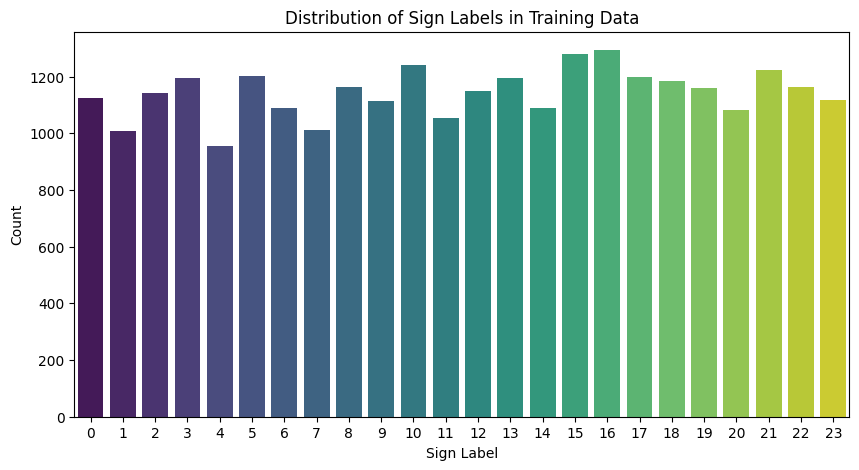

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(x='label', data=train_df, palette='viridis')
plt.title("Distribution of Sign Labels in Training Data")
plt.xlabel("Sign Label")
plt.ylabel("Count")
plt.show()

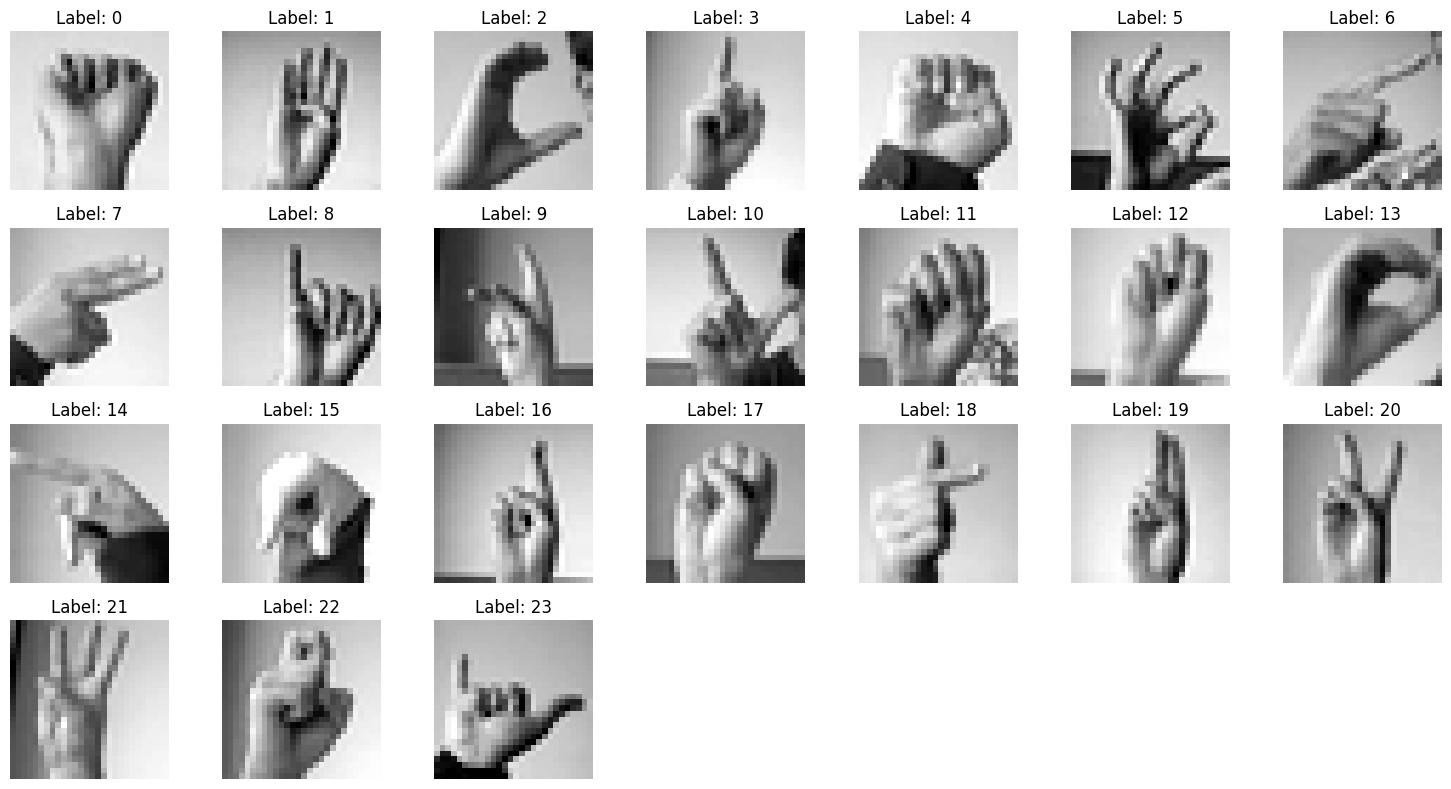

In [29]:
unique_labels = train_df['label'].unique()

plt.figure(figsize=(15, 8))
for i, label in enumerate(sorted(unique_labels)):
    img = train_df[train_df['label'] == label].iloc[0, 1:].values.reshape(28, 28)
    
    plt.subplot(4, 7, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


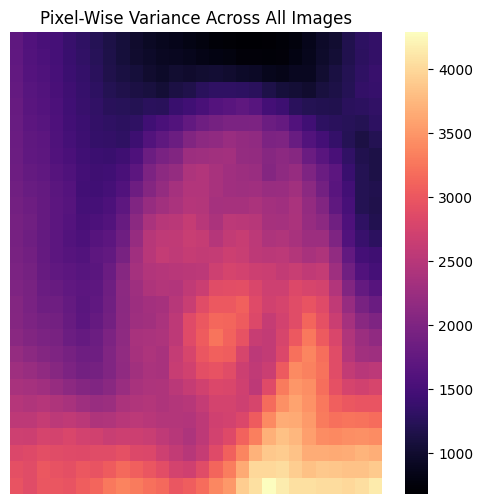

In [30]:
pixel_variance = train_df.iloc[:, 1:].var(axis=0).values.reshape(28, 28)

plt.figure(figsize=(6,6))
sns.heatmap(pixel_variance, cmap='magma')
plt.title("Pixel-Wise Variance Across All Images")
plt.axis('off')
plt.show()


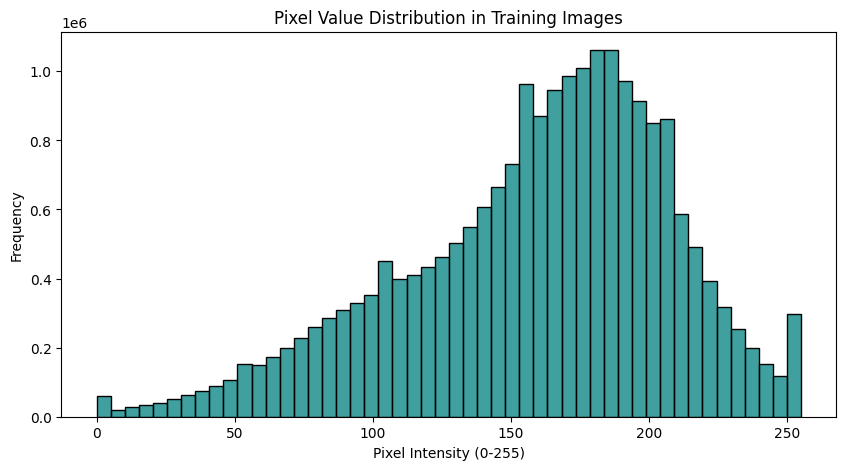

In [31]:
all_pixels = train_df.iloc[:, 1:].values.flatten()

plt.figure(figsize=(10,5))
sns.histplot(all_pixels, bins=50, color='teal')
plt.title("Pixel Value Distribution in Training Images")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.show()

In [32]:
X_train = train_df.drop("label", axis=1).values / 255.0
y_train = train_df["label"].values
X_test = test_df.drop("label", axis=1).values / 255.0
y_test = test_df["label"].values

X_train = torch.tensor(X_train.reshape(-1, 1, 28, 28), dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test.reshape(-1, 1, 28, 28), dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)


In [33]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

In [34]:
class UNetClassifier(nn.Module):
    def __init__(self, in_channels=1, num_classes=24, features=[64, 128, 256]):
        super(UNetClassifier, self).__init__()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)

        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        self.ups = nn.ModuleList()
        self.up_convs = nn.ModuleList()
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.up_convs.append(DoubleConv(feature*2, feature))

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(features[0], num_classes)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(len(self.ups)):
            x = self.ups[i](x)
            if x.shape != skips[i].shape:
                x = F.interpolate(x, size=skips[i].shape[2:])
            x = torch.cat((skips[i], x), dim=1)
            x = self.up_convs[i](x)
        x = self.global_pool(x).view(x.size(0), -1)
        return self.fc(x)


In [35]:
model = UNetClassifier().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [36]:
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
  
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            val_loss += criterion(output, target).item()
    

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Val Loss: {val_loss/len(val_loader):.4f}")

Epoch 1/5
Train Loss: 1.3502
Val Loss: 0.5621
Epoch 2/5
Train Loss: 0.2447
Val Loss: 0.0354
Epoch 3/5
Train Loss: 0.0767
Val Loss: 0.0476
Epoch 4/5
Train Loss: 0.0422
Val Loss: 0.0103
Epoch 5/5
Train Loss: 0.0585
Val Loss: 0.1188


In [ ]:
model.eval()
test_loss = 0.0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += criterion(output, target).item()

print(f"Final Test Loss: {test_loss/len(test_loader):.4f}")

torch.save(model.state_dict(), "unet_weights.pth")

Final Test Loss: 0.1074


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            preds = output.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')
    f1 = f1_score(all_targets, all_preds, average='weighted')
    return accuracy, precision, recall, f1

test_accuracy, test_precision, test_recall, test_f1 = get_metrics(model, test_loader)

In [ ]:
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

Accuracy:  0.9670
Precision: 0.9701
Recall:    0.9670
F1 Score:  0.9667


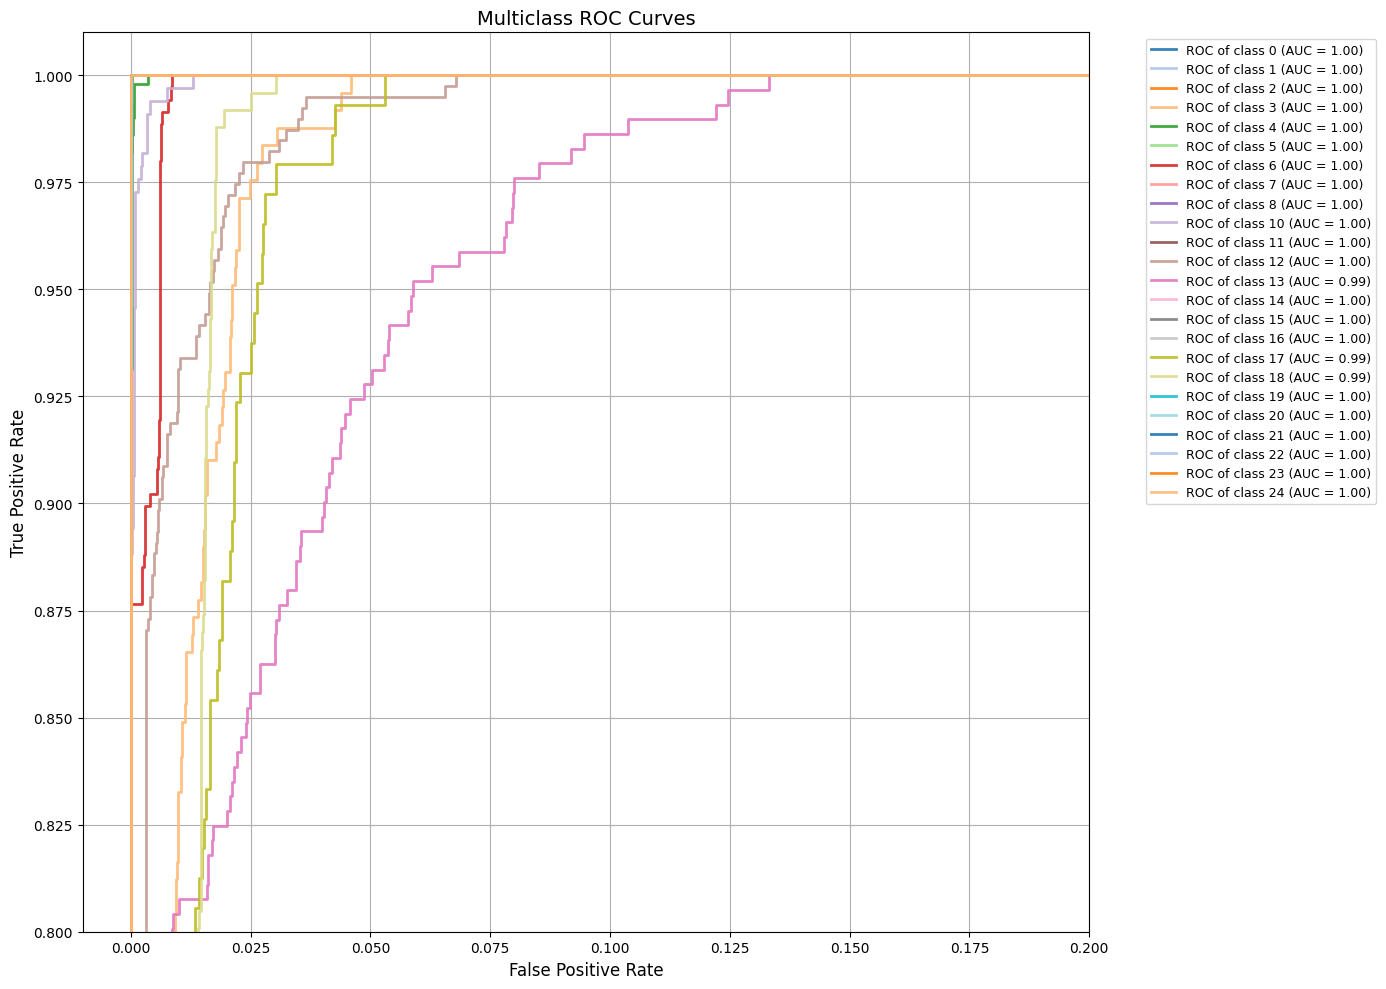

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import torch 

def plot_roc_curves(model, loader, class_labels):
    model.eval()
    all_probs = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            probs = torch.softmax(output, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(target.cpu().numpy())
    
    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)
    
    n_classes = len(class_labels)
    y_true = label_binarize(all_targets, classes=np.arange(n_classes))
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    plt.figure(figsize=(14, 10))
    colors = cycle(plt.cm.tab20.colors)  
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2, alpha=0.9,
                 label='ROC of class {0} (AUC = {1:0.2f})'.format(class_labels[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.01, 0.2])  
    plt.ylim([0.8, 1.01])  
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Multiclass ROC Curves', fontsize=14)
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

class_labels = [str(i) for i in sorted(label_map.keys()) if i != 9]

plot_roc_curves(model, test_loader, class_labels)


In [39]:
from sklearn.metrics import classification_report
import pandas as pd
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        preds = torch.argmax(output, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

report = classification_report(all_targets, all_preds, 
                              target_names=list(label_map.values()),
                              output_dict=True)
pd.DataFrame(report).transpose().style.background_gradient()

,precision,recall,f1-score,support
0,1.000000,0.734139,0.846690,331.000000
1,1.000000,0.993056,0.996516,432.000000
2,0.996785,1.000000,0.998390,310.000000
3,0.850000,0.763265,0.804301,245.000000
4,1.000000,0.951807,0.975309,498.000000
5,1.000000,1.000000,1.000000,247.000000
6,0.887978,0.933908,0.910364,348.000000
7,0.949891,1.000000,0.974302,436.000000
8,1.000000,0.885417,0.939227,288.000000
9,0.640232,1.000000,0.780660,331.000000
